**Import dependencies**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"


**Check prediction quality**

In [17]:
# Load data
data = pd.read_csv("test_log_kernel.csv")

tau_ext = data.filter(like="tau_ext_").to_numpy()[1:, :] # shape (T, 7)
predictions = data.filter(like="friction_pred_").to_numpy()[1:, :] # shape (T, 7)

print("tau_ext shape:", tau_ext.shape)
print("predictions shape:", predictions.shape)

tau_ext shape: (32500, 7)
predictions shape: (32500, 7)


**Plot predictions**

Joint 0: RMSE = 0.0764 Nm
Joint 1: RMSE = 0.1458 Nm
Joint 2: RMSE = 0.0169 Nm
Joint 3: RMSE = 0.0347 Nm
Joint 4: RMSE = 0.0107 Nm
Joint 5: RMSE = 0.0091 Nm
Joint 6: RMSE = 0.0079 Nm


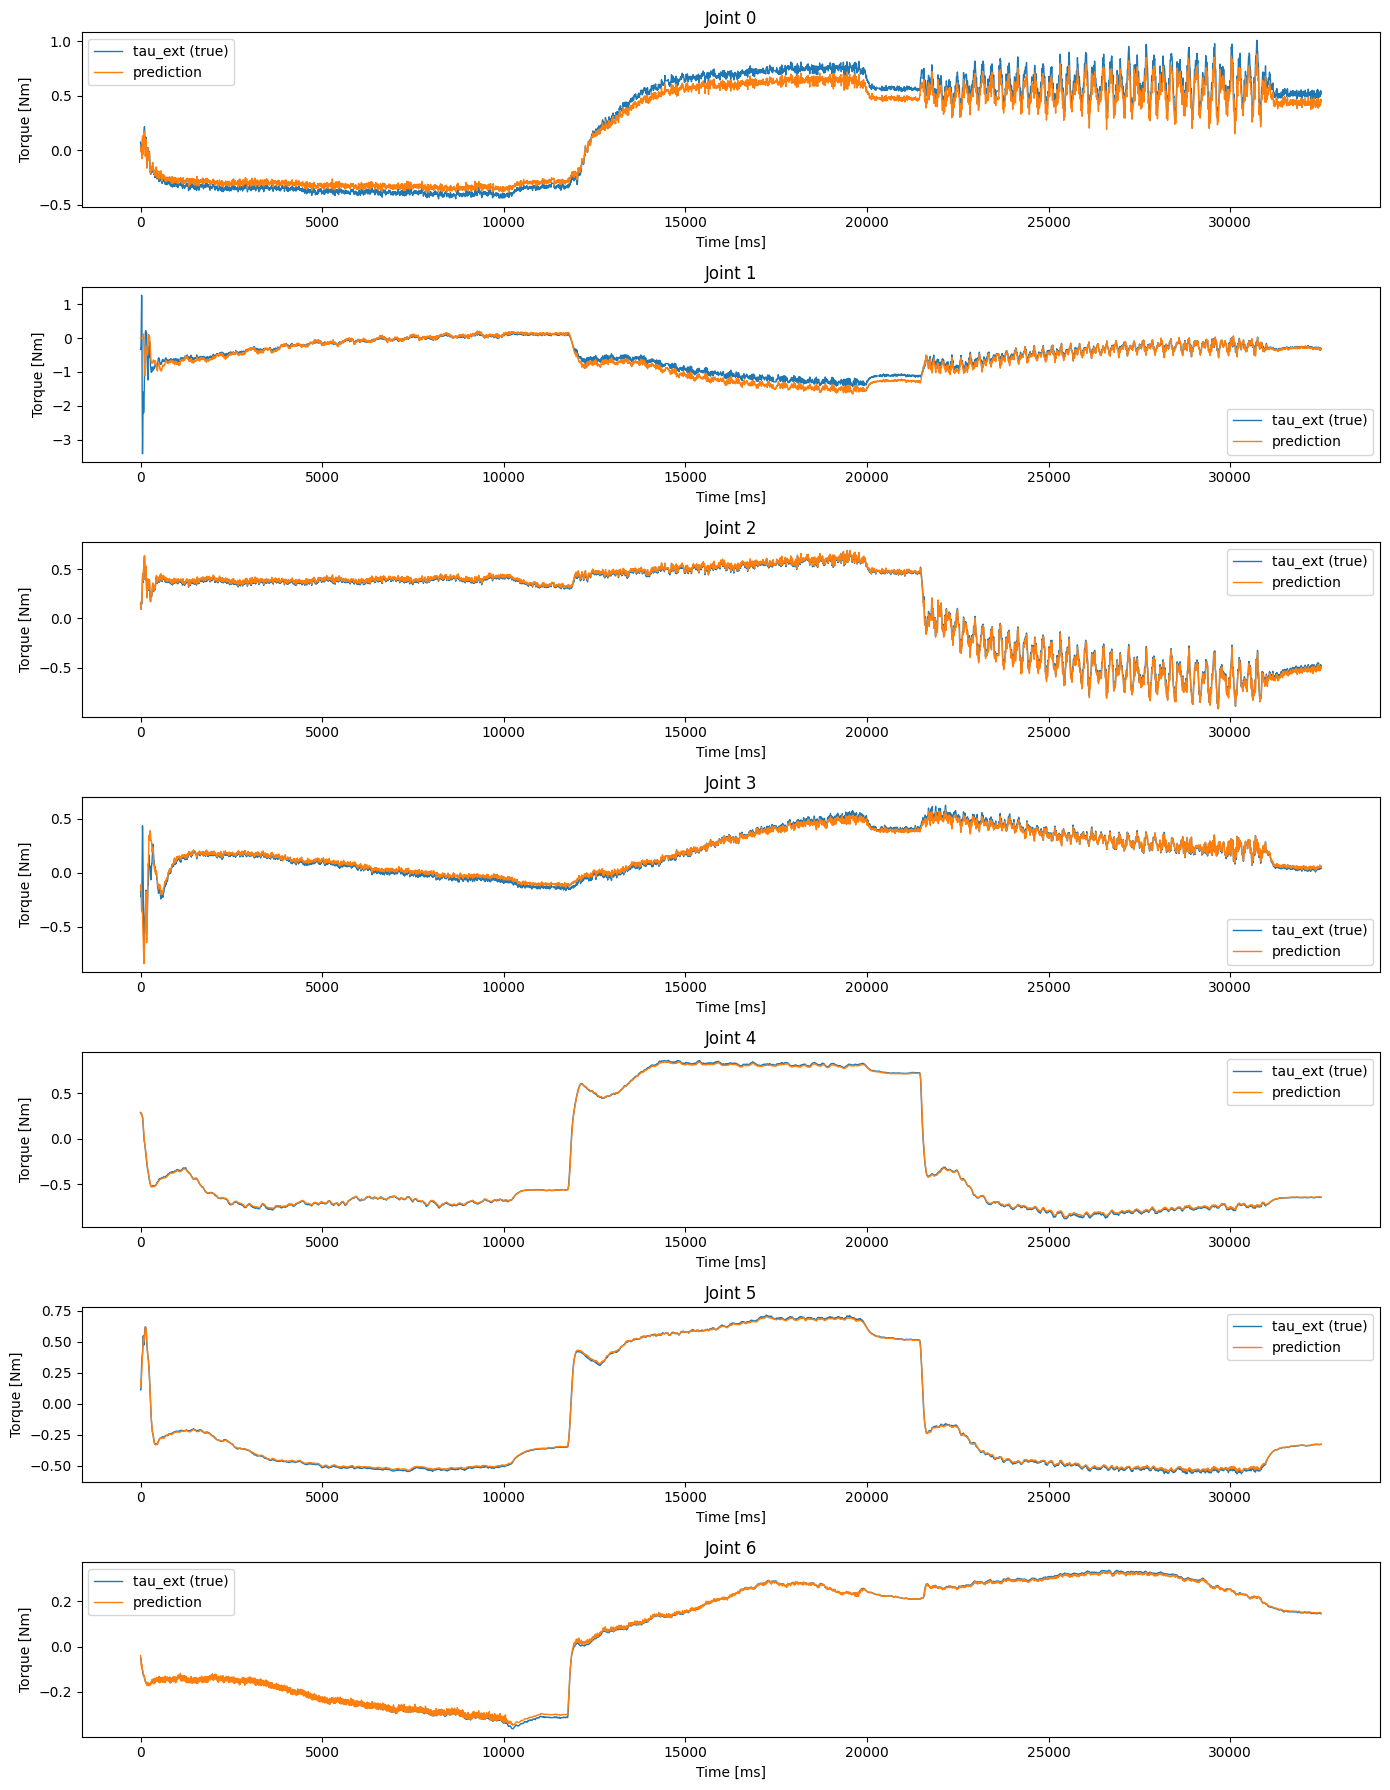

In [18]:
num_joints = tau_ext.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):

    err = tau_ext[:, i] - predictions[:, i]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {i}: RMSE = {rmse:.4f} Nm")
    
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(predictions[:, i], label="prediction", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()

**Load residuals**

In [4]:
# Load data
data = pd.read_csv("test_log_kernel.csv")

residuals = data.filter(like="residual_").to_numpy()[1:, :] # shape (T, 7)

print("residuals_full shape:", residuals.shape)

residuals_full shape: (32502, 7)


**PLot residuals vs tau_ext**

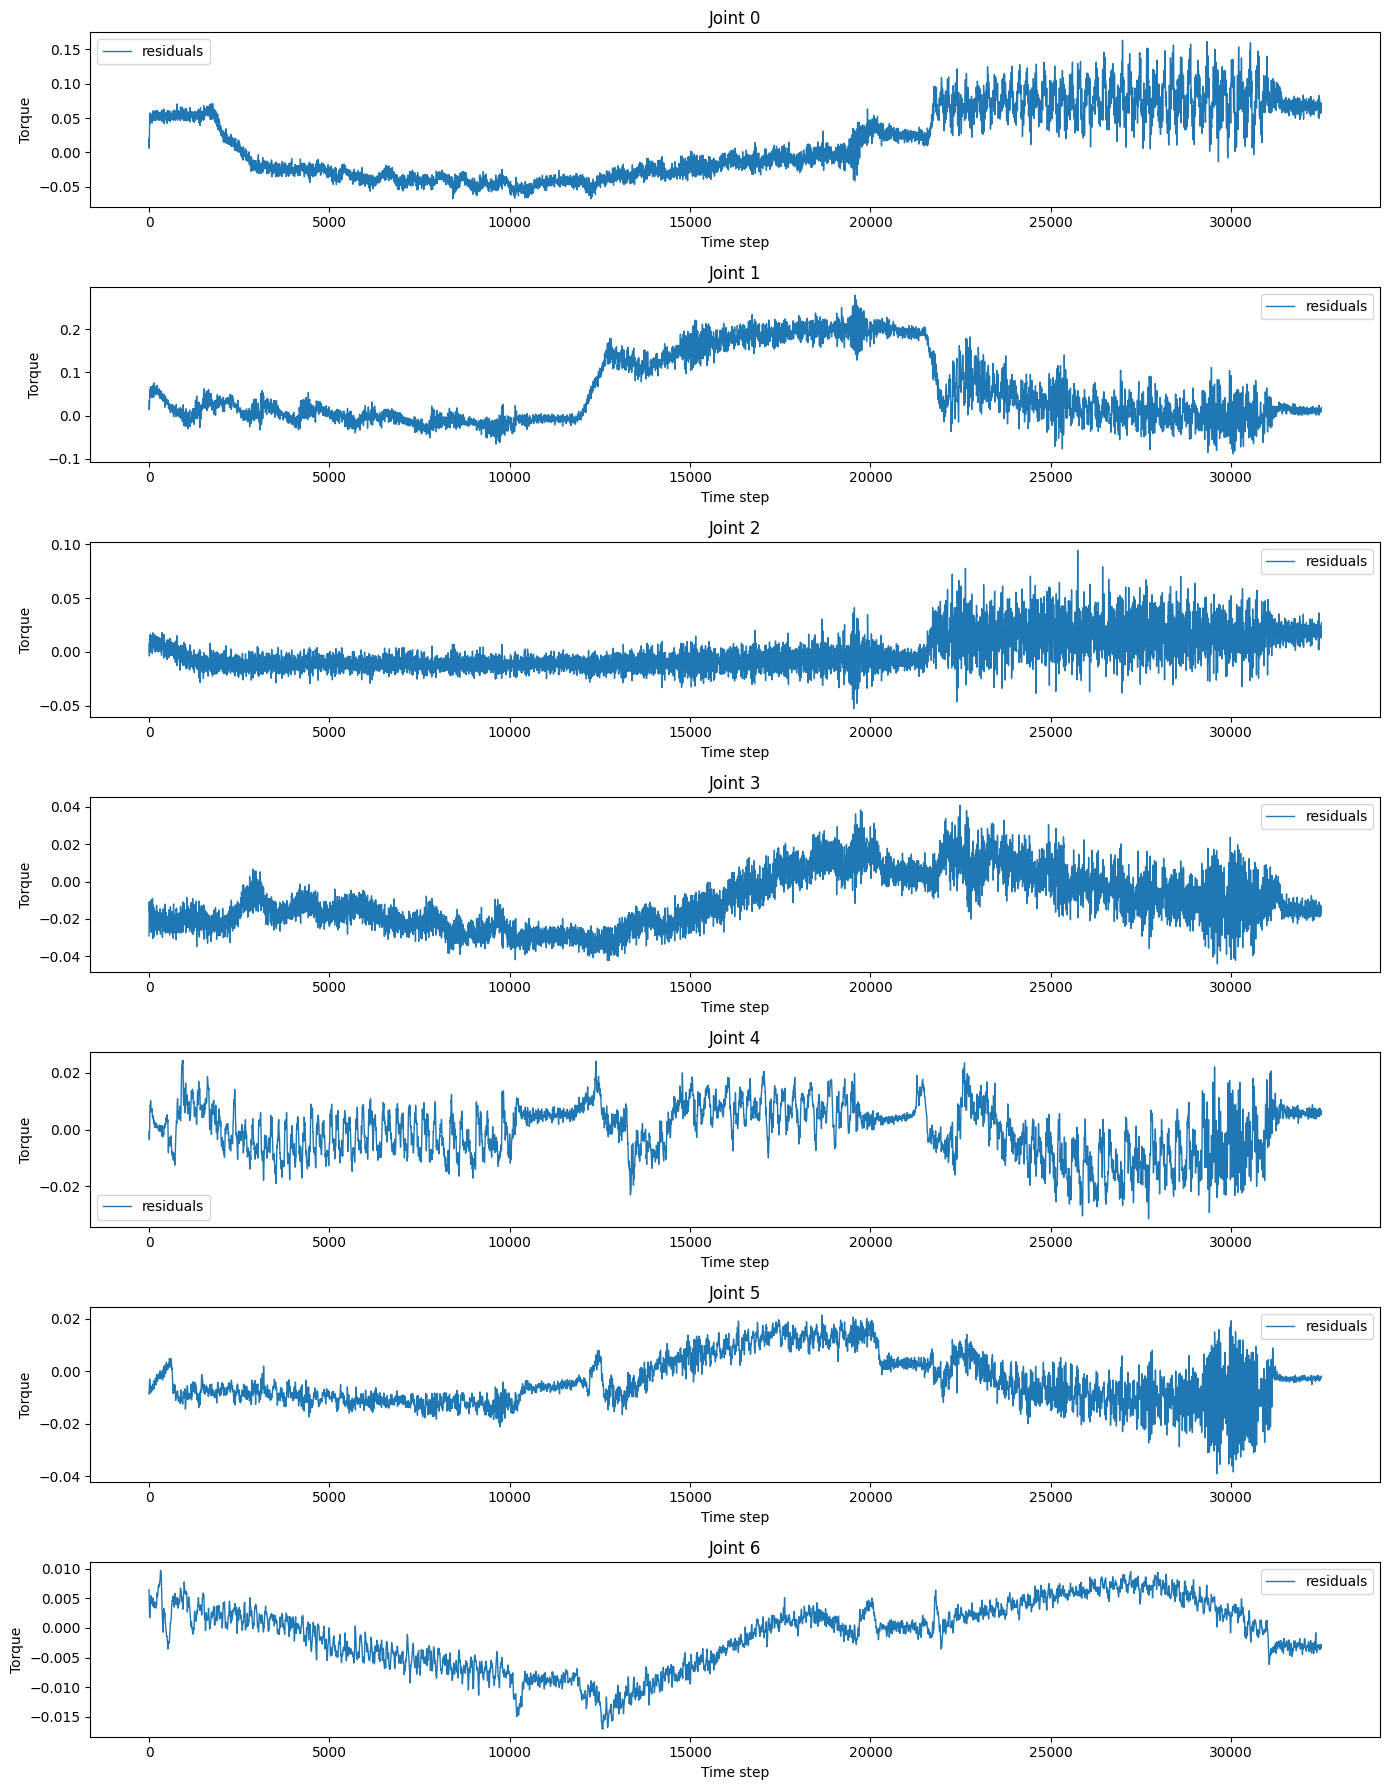

In [5]:
num_joints = residuals.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(residuals[:, i], label="residuals", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Torque")
    plt.legend()

plt.tight_layout()
plt.show()

**Load joint positions**

In [15]:
# Load data
data = pd.read_csv("test_log.csv")
kernel_data = pd.read_csv("test_log_kernel.csv")

q_des = data.filter(like="q_des_").to_numpy()[1:, :] # shape (T, 7)
q_curr = data.filter(like="q_curr_").to_numpy()[1:, :]# shape (T, 7)
q_curr_kernel = kernel_data.filter(like="q_curr_").to_numpy()[1:32739, :] # shape (T, 7)

T = min(len(q_curr), len(q_curr_kernel))

q_des = q_des[1:T, :]
q_curr = q_curr[1:T, :]
q_curr_kernel = q_curr_kernel[1:T, :]

print("q_des shape:", q_des.shape)
print("q_curr shape:", q_curr.shape)
print("q_curr_kernel shape:", q_curr_kernel.shape)

q_des shape: (32498, 7)
q_curr shape: (32498, 7)
q_curr_kernel shape: (32498, 7)


**Plot tracking quality**

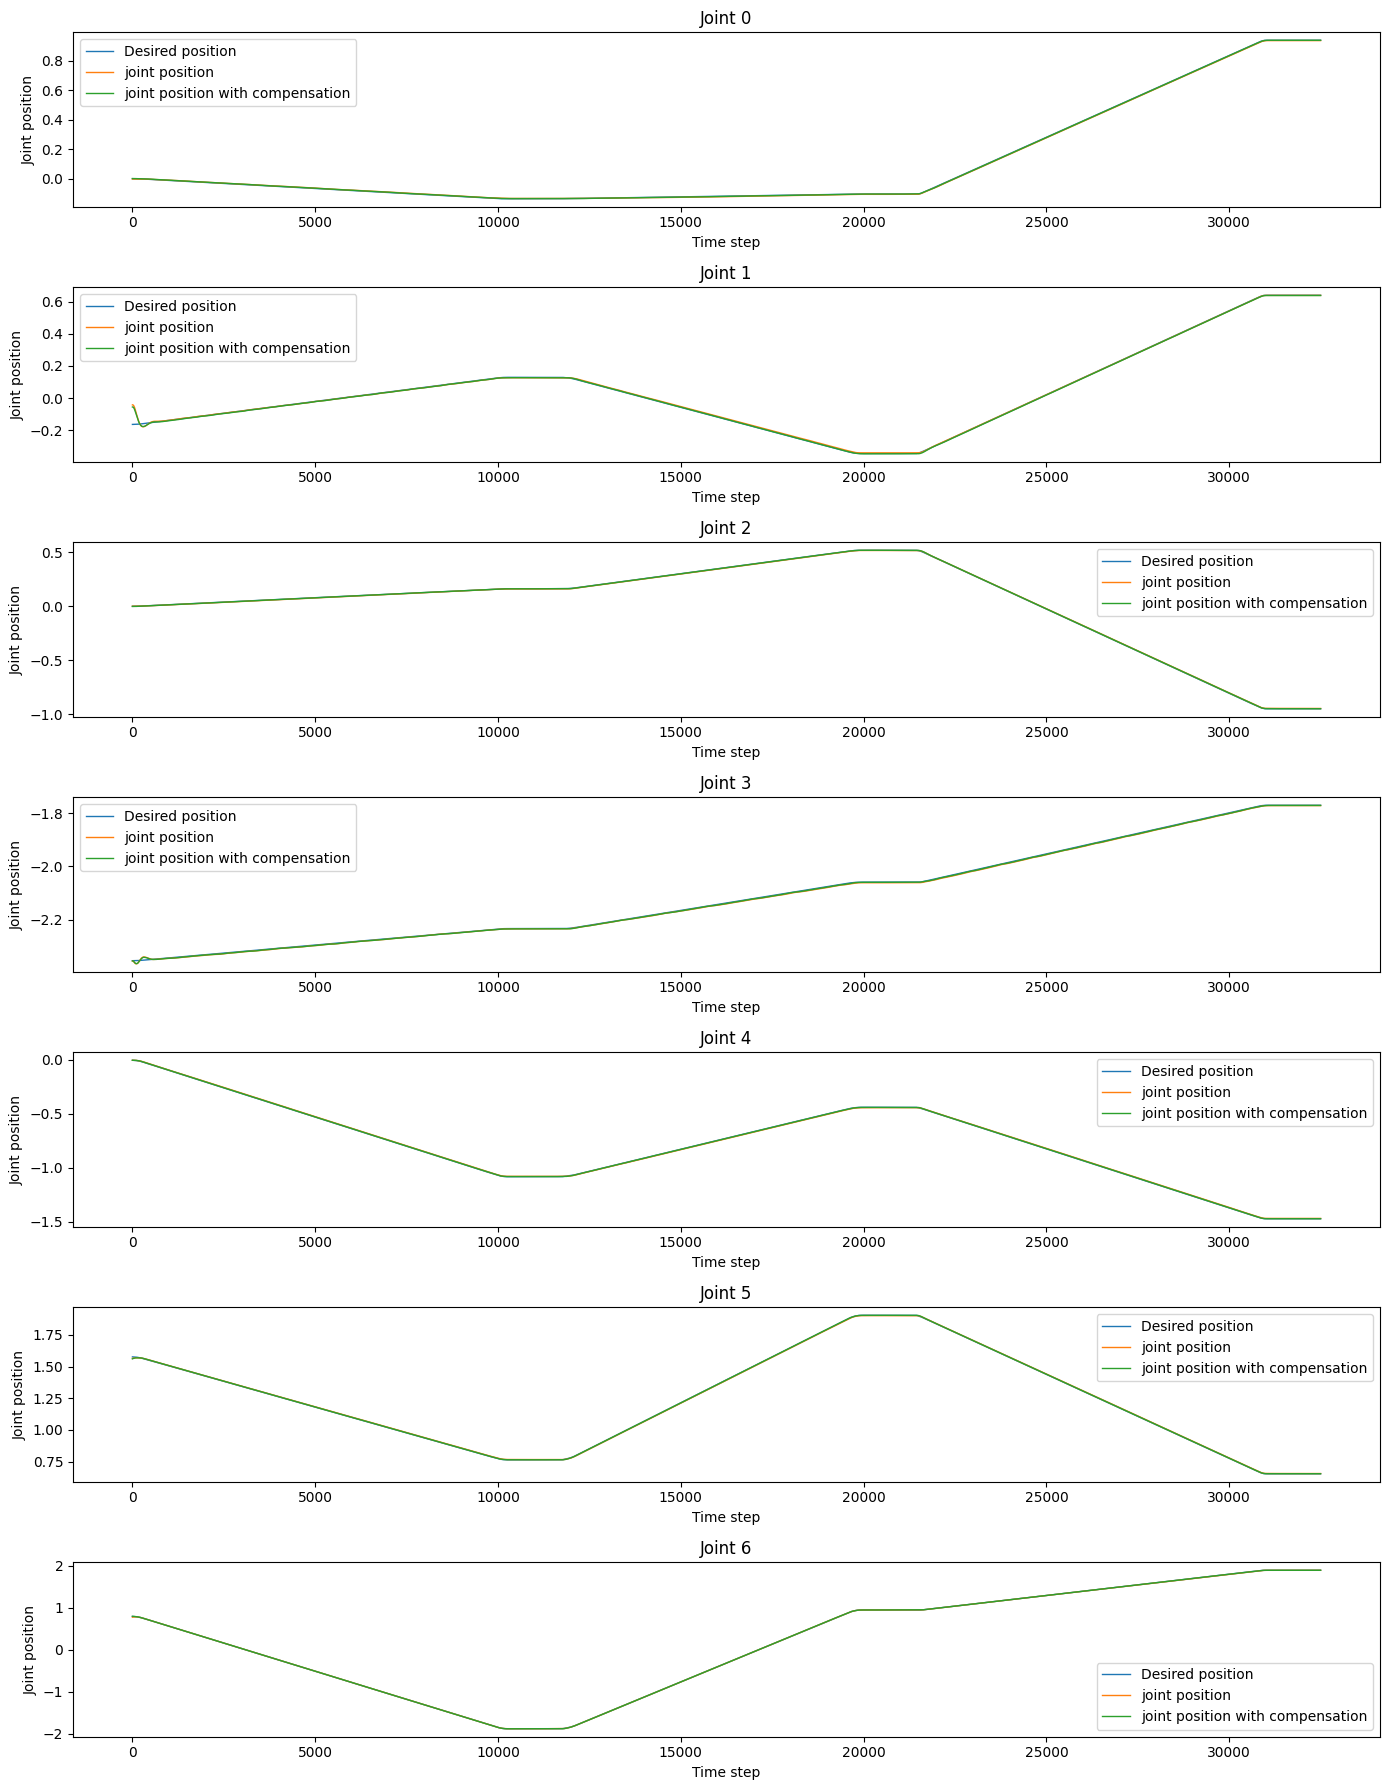

Joint 0: RMSE no-ff = 0.00304, with-ff = 0.00169
Joint 1: RMSE no-ff = 0.00708, with-ff = 0.00600
Joint 2: RMSE no-ff = 0.00278, with-ff = 0.00128
Joint 3: RMSE no-ff = 0.00253, with-ff = 0.00180
Joint 4: RMSE no-ff = 0.00385, with-ff = 0.00146
Joint 5: RMSE no-ff = 0.00279, with-ff = 0.00120
Joint 6: RMSE no-ff = 0.00179, with-ff = 0.00093


In [16]:
num_joints = q_des.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(q_des[:, i], label="Desired position", linewidth=1.0)
    plt.plot(q_curr[:, i], label="joint position", linewidth=1.0)
    plt.plot(q_curr_kernel[:, i], label="joint position with compensation", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Joint position")
    plt.legend()

plt.tight_layout()
plt.show()

def rmse(a, b):
    err = a - b
    return np.sqrt(np.mean(err**2))

for j in range(num_joints):
    rmse_noff = rmse(q_curr[:, j], q_des[:, j])
    rmse_ff = rmse(q_curr_kernel[:, j],   q_des[:, j])
    print(f"Joint {j}: RMSE no-ff = {rmse_noff:.5f}, with-ff = {rmse_ff:.5f}")


**Load cartesian positions**

In [22]:
# Load data
ref = pd.read_csv("cartesian_ref.csv")
data = pd.read_csv("test_log.csv")
kernel_data = pd.read_csv("test_log_kernel.csv")

# Extract time vectors (seconds)
t_data = data["time_s"].to_numpy()
t_kernel = kernel_data["time_s"].to_numpy()
t_ref = ref["time_s"].to_numpy()

# Extract Cartesian positions
x_data, y_data, z_data = data["x"].to_numpy(), data["y"].to_numpy(), data["z"].to_numpy()
x_kernel, y_kernel, z_kernel = kernel_data["x"].to_numpy(), kernel_data["y"].to_numpy(), kernel_data["z"].to_numpy()
x_ref, y_ref, z_ref = ref["x"].to_numpy(), ref["y"].to_numpy(), ref["z"].to_numpy()

# Build common 1 ms time grid over the interval where logs overlap
t_start = max(t_data[1], t_kernel[0], t_ref[0])
t_end = min(t_data[-1], t_kernel[-1], t_ref[-1])

dt = 0.001  # 1 ms
t_common = np.arange(t_start, t_end, dt)

# Interpolate everything onto t_common
x_ref_i = np.interp(t_common, t_ref, x_ref)
y_ref_i = np.interp(t_common, t_ref, y_ref)
z_ref_i = np.interp(t_common, t_ref, z_ref)

x_data_i = np.interp(t_common, t_data, x_data)
y_data_i = np.interp(t_common, t_data, y_data)
z_data_i = np.interp(t_common, t_data, z_data)

x_kernel_i = np.interp(t_common, t_kernel, x_kernel)
y_kernel_i = np.interp(t_common, t_kernel, y_kernel)
z_kernel_i = np.interp(t_common, t_kernel, z_kernel)

xyz_ref = np.stack([x_ref_i, y_ref_i, z_ref_i], axis=1)
xyz_data = np.stack([x_data_i, y_data_i, z_data_i], axis=1)
xyz_kernel = np.stack([x_kernel_i, y_kernel_i, z_kernel_i], axis=1)

# Per-axis position errors
err_no_comp_xyz = xyz_data - xyz_ref
err_comp_xyz = xyz_kernel - xyz_ref

print("t_common shape:", t_common.shape)
print("xyz_ref shape:", xyz_ref.shape)
print("xyz_data shape:", xyz_data.shape)
print("xyz_kernel shape:", xyz_kernel.shape)

print(z_data_i[-1])
print(z_kernel_i[-1])
print(z_ref_i[-1])


t_common shape: (31585,)
xyz_ref shape: (31585, 3)
xyz_data shape: (31585, 3)
xyz_kernel shape: (31585, 3)
0.5621187220842573
0.563449673416009
0.5625386144735096


**Plot cartesian positions**

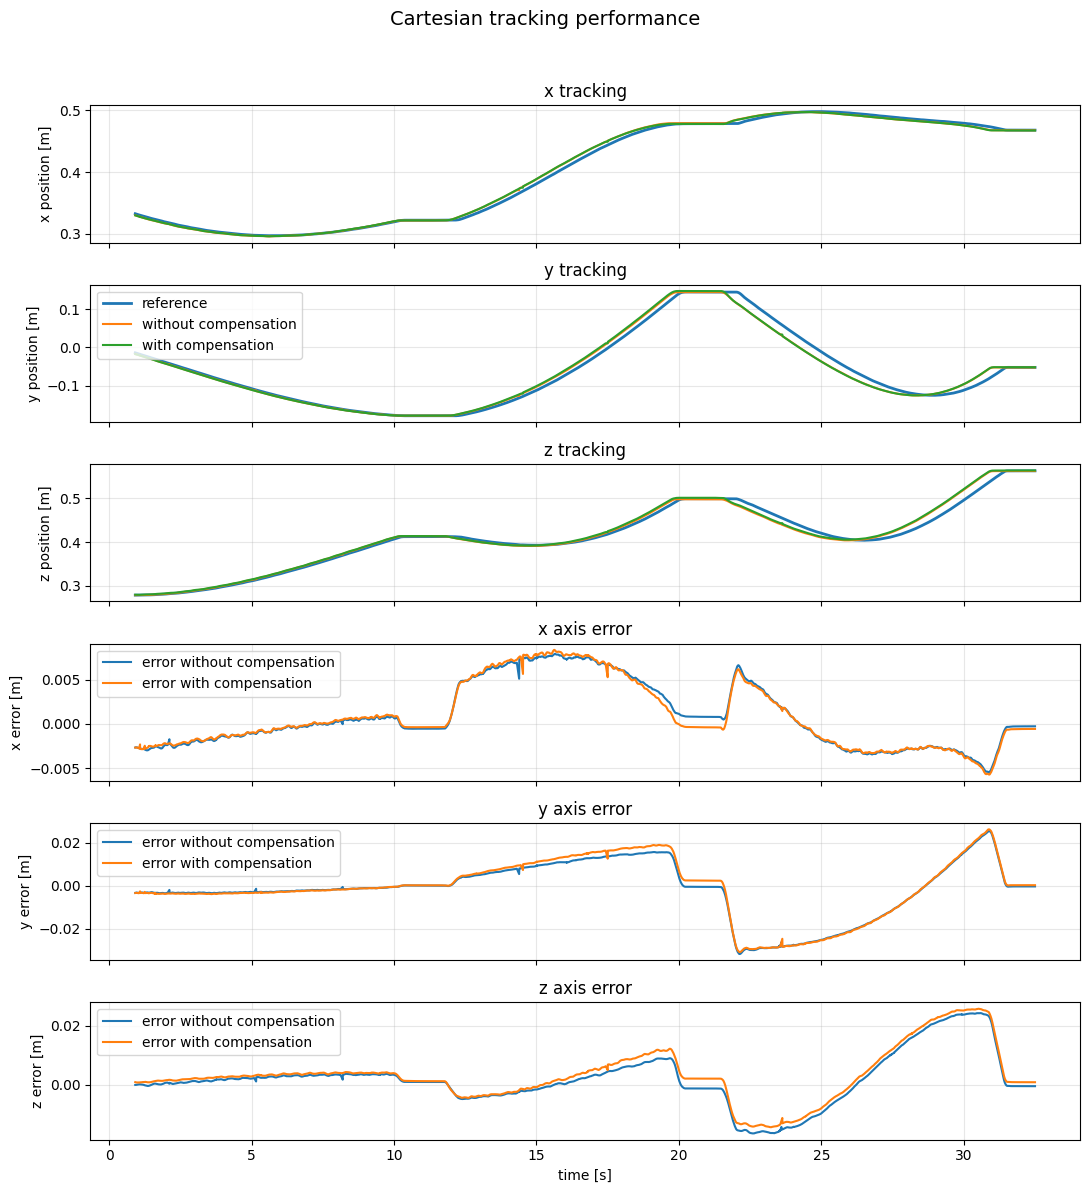

In [12]:

labels = ["x", "y", "z"]
units = "position [m]"

fig, axes = plt.subplots(6, 1, figsize=(11, 12), sharex=True)

# x, y, z tracking (axes 0,1,2)
for i, ax in enumerate(axes[:3]):
    ax.plot(t_common, xyz_ref[:, i], label="reference", linewidth=2)
    ax.plot(t_common, xyz_data[:, i], label="without compensation", linewidth=1.5)
    ax.plot(t_common, xyz_kernel[:, i], label="with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} {units}")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} tracking")

axes[1].legend(loc="upper left")

# x, y, z errors (axes 3,4,5)
for i, ax in enumerate(axes[3:6]):
    ax.plot(t_common, err_no_comp_xyz[:, i], label="error without compensation", linewidth=1.5)
    ax.plot(t_common, err_comp_xyz[:, i], label="error with compensation", linewidth=1.5)
    ax.set_ylabel(f"{labels[i]} error [m]")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} axis error")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("time [s]")

fig.suptitle("Cartesian tracking performance", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



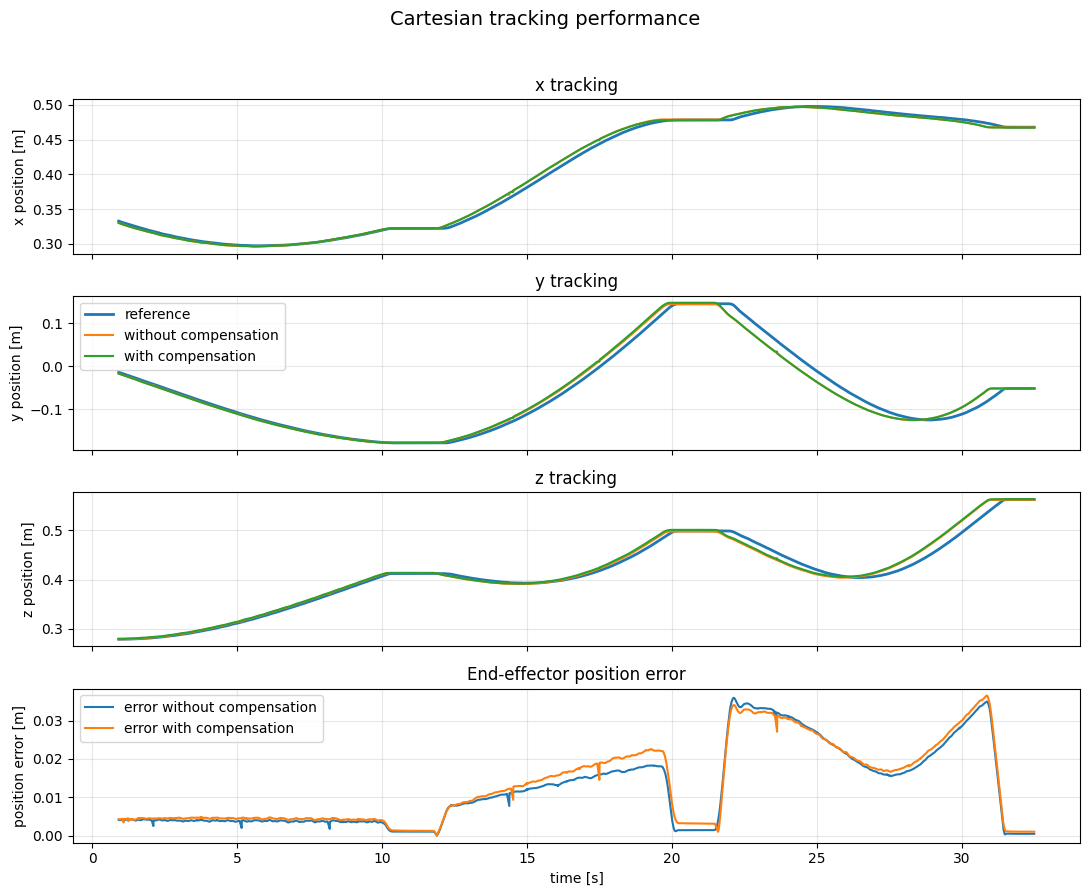

In [13]:
err_no_comp = np.linalg.norm(xyz_data - xyz_ref, axis=1) 
err_comp = np.linalg.norm(xyz_kernel - xyz_ref, axis=1)

labels = ["x", "y", "z"]
units = "position [m]"

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

# x, y, z tracking
for i, ax in enumerate(axes[:3]):
    ax.plot(t_common, xyz_ref[:, i], label="reference", linewidth=2)
    ax.plot(t_common, xyz_data[:, i], label="without compensation", linewidth=1.5)
    ax.plot(t_common, xyz_kernel[:, i], label="with compensation", linewidth=1.5)

    ax.set_ylabel(f"{labels[i]} {units}")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"{labels[i]} tracking")

# Only one legend (on the middle plot, for example)
axes[1].legend(loc="upper left")

# End-effector error subplot
axes[3].plot(t_common, err_no_comp, label="error without compensation", linewidth=1.5)
axes[3].plot(t_common, err_comp, label="error with compensation", linewidth=1.5)
axes[3].set_ylabel("position error [m]")
axes[3].set_xlabel("time [s]")
axes[3].set_title("End-effector position error")
axes[3].grid(True, alpha=0.3)
axes[3].legend(loc="upper left")

fig.suptitle("Cartesian tracking performance", fontsize=14, y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**For fun**

In [19]:
fig = go.Figure()

# Trajectories
fig.add_trace(go.Scatter3d(
    x=xyz_ref[:, 0], y=xyz_ref[:, 1], z=xyz_ref[:, 2],
    mode='lines',
    line=dict(color='blue', width=5),
    name='reference'
))

fig.add_trace(go.Scatter3d(
    x=xyz_data[:, 0], y=xyz_data[:, 1], z=xyz_data[:, 2],
    mode='lines',
    line=dict(color='orange', width=3),
    name='without compensation'
))

fig.add_trace(go.Scatter3d(
    x=xyz_kernel[:, 0], y=xyz_kernel[:, 1], z=xyz_kernel[:, 2],
    mode='lines',
    line=dict(color='green', width=3),
    name='with compensation'
))

def add_start_end_markers(xyz, label_prefix, color):
    """Add start and end markers to the 3D plotly figure."""
    # Start marker
    fig.add_trace(go.Scatter3d(
        x=[xyz[0, 0]], y=[xyz[0, 1]], z=[xyz[0, 2]],
        mode='markers',
        marker=dict(size=5, color=color, symbol='circle'),
        name=f"{label_prefix} start"
    ))
    # End marker
    fig.add_trace(go.Scatter3d(
        x=[xyz[-1, 0]], y=[xyz[-1, 1]], z=[xyz[-1, 2]],
        mode='markers',
        marker=dict(size=6, color=color, symbol='x'),
        name=f"{label_prefix} end"
    ))

# Add markers for each trajectory
add_start_end_markers(xyz_ref, "ref", "blue")
add_start_end_markers(xyz_data, "no compensation", "orange")
add_start_end_markers(xyz_kernel, "with compensation", "green")

# Layout and styling
fig.update_layout(
    title="End-effector trajectory in Cartesian space",
    template="plotly_white",
    scene=dict(
        xaxis_title='x [m]',
        yaxis_title='y [m]',
        zaxis_title='z [m]',
        xaxis=dict(backgroundcolor="white",
                   gridcolor="lightgray",
                   zerolinecolor="gray"),
        yaxis=dict(backgroundcolor="white",
                   gridcolor="lightgray",
                   zerolinecolor="gray"),
        zaxis=dict(backgroundcolor="white",
                   gridcolor="lightgray",
                   zerolinecolor="gray"),
        aspectmode='data',
        camera=dict(eye=dict(x=1.6, y=1.4, z=1.2))
    ),
    legend=dict(
        x=0.01, y=0.99,
        bgcolor="rgba(255,255,255,0.6)",
        bordercolor="lightgray",
        borderwidth=1
    ),
    margin=dict(l=10, r=10, t=60, b=10),
)

fig.show()

/snap/core20/current/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.29' not found (required by /lib/x86_64-linux-gnu/libproxy.so.1)
Failed to load module: /home/anthony-ho/snap/code/common/.cache/gio-modules/libgiolibproxy.so
Gtk-Message: 17:04:48.517: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
